<a href="https://colab.research.google.com/github/kngtm1/DATA607_WaterData_Project/blob/main/data_607_final_project_logistic_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Model

In [1]:
# 1. Imports
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt


In [2]:
# 2. Read in the datasets
train_df = pd.read_csv('https://raw.githubusercontent.com/kngtm1/DATA607_WaterData_Project/refs/heads/main/data/train_set.csv')
test_df  = pd.read_csv('https://raw.githubusercontent.com/kngtm1/DATA607_WaterData_Project/refs/heads/main/data/test_set.csv')

# 3. Split into X and y
X_train = train_df.drop(columns=["contaminated"])
y_train = train_df["contaminated"]

X_test = test_df.drop(columns=["contaminated"])
y_test = test_df["contaminated"]

In [3]:
# 4. Build pipelines

# A. Logistic Regression with no penalty
pipe_none = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty= None,
        solver="lbfgs",
        max_iter=1000
    ))
])

# B. Logistic Regression with L2 penalty
pipe_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000
    ))
])

In [4]:
# fit models
pipe_none.fit(X_train, y_train)
pipe_l2.fit(X_train, y_train)

# Predictions
y_pred_none = pipe_none.predict(X_test)
y_pred_l2   = pipe_l2.predict(X_test)

In [5]:
# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name}")
    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(model_name)
    plt.show()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


Logistic Regression - No Penalty
Confusion Matrix:
[[896 171]
 [275 675]]


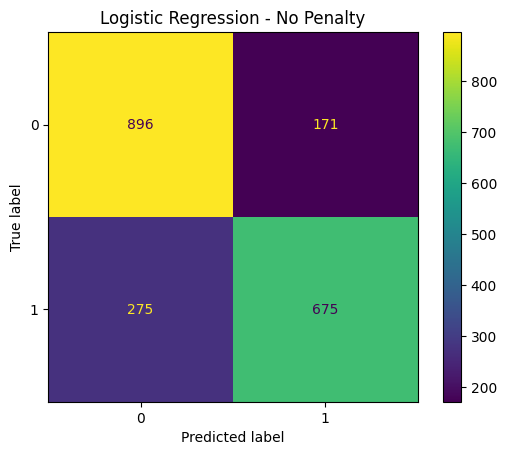

Accuracy : 0.7789
Precision: 0.7979
Recall   : 0.7105
F1 Score : 0.7517


In [6]:
evaluate_model(y_test, y_pred_none, "Logistic Regression - No Penalty")

### Choice of Regularization Method

L2 regularization was selected as the final regularization method for the logistic regression model. The dataset contains multiple water chemistry variables that are likely correlated, such as nitrate, nitrite, ammonia, and other nutrient-related measurements. L2 regularization is well suited for this situation because it shrinks coefficients smoothly and distributes importance across correlated predictors rather than eliminating them entirely.

In contrast, L1 regularization performs feature selection by forcing some coefficients to zero. While this can be useful in high-dimensional datasets with many irrelevant predictors, the variables in this dataset represent meaningful environmental measurements and should not be arbitrarily removed from the model.

Additionally, the dataset contains a moderate number of predictors relative to the number of observations, so feature sparsity is not a primary concern. For these reasons, L2 regularization provides a more stable and interpretable model for this classification task.

In [ ]:
evaluate_model(y_test, y_pred_l2,   "Logistic Regression - L2 Penalty")

## Model Optimization Approach

After training baseline logistic regression models (no penalty, and L2 penalty), the next step was to optimize the model using hyperparameter tuning. The goal of model optimization is to identify the set of model parameters that produces the best predictive performance while maintaining generalization to unseen data.

For logistic regression, the primary hyperparameter controlling model complexity is the regularization strength parameter \(C\). Regularization helps prevent overfitting by penalizing large coefficient values. Smaller values of \(C\) correspond to stronger regularization, while larger values of \(C\) allow the model coefficients to vary more freely.

To systematically search for the best hyperparameters, a grid search procedure was implemented.

## Grid Search for Hyperparameter Tuning

Hyperparameter tuning was performed using **GridSearchCV** from scikit-learn. Grid search evaluates multiple combinations of hyperparameters and selects the configuration that produces the best performance according to a specified evaluation metric.

The following hyperparameters were tuned:

- **Regularization strength (C):** Tested across a wide range of values using a logarithmic scale to capture both strong and weak regularization levels.
- **Class weight:** Both `None` and `"balanced"` were tested. The `"balanced"` option adjusts class weights automatically based on class frequencies and can improve performance when datasets are imbalanced.

## Cross-Validation Strategy

Model performance during hyperparameter tuning was evaluated using **Stratified K-Fold Cross-Validation** with 5 folds.

Stratified cross-validation ensures that each fold maintains approximately the same class distribution as the full dataset. This is particularly important for classification problems where class imbalance may exist.

Using cross-validation improves the robustness of the hyperparameter selection process by evaluating model performance across multiple training and validation splits rather than relying on a single split of the data.

## Evaluation Metric

The optimization procedure used **F1 score** as the evaluation metric.

The F1 score is the harmonic mean of precision and recall:

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

F1 score was chosen because it balances the trade-off between false positives and false negatives. In many classification problems, accuracy alone can be misleading, particularly if one class is more frequent than the other. By optimizing F1 score, the model is encouraged to maintain both high precision and high recall.

## Final Model Selection

After performing grid search, the model configuration with the highest cross-validation F1 score was selected as the optimized model. This model was then evaluated on the held-out test dataset to assess its performance on unseen data.

Using this optimization procedure helps ensure that the final model balances predictive performance and generalization, reducing the risk of overfitting while improving classification accuracy.

In [ ]:
# =========================
# 1. Imports for grid search
# =========================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# =========================
# 2. Define base pipeline
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

# =========================
# 3. Define parameter grid
# =========================
param_grid = {
    "logreg__C": [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 10000],
    "logreg__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 4. Grid Search
# =========================
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

In [ ]:
# =========================
# 5. Predict using best model
# =========================
best_model = grid.best_estimator_

y_pred_grid = best_model.predict(X_test)

# =========================
# 6. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_grid)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Optimized Logistic Regression")
plt.show()

# =========================
# 7. Metrics
# =========================
accuracy = accuracy_score(y_test, y_pred_grid)
precision = precision_score(y_test, y_pred_grid)
recall = recall_score(y_test, y_pred_grid)
f1 = f1_score(y_test, y_pred_grid)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

In [ ]:
# Extract the trained logistic regression model from the pipeline
logreg_model = best_model.named_steps["logreg"]

# Get feature names
feature_names = X_train.columns

# Extract coefficients
coefficients = logreg_model.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute importance
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

# Display results
print("Logistic Regression Coefficients (Optimized Model):\n")
display(coef_df[["Feature", "Coefficient"]])

In [ ]:
best_model.named_steps["logreg"].intercept_

In [ ]:
import matplotlib.pyplot as plt

# Get top 10 features by absolute coefficient
top10 = coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

# Sort for nicer plotting (largest at top)
top10 = top10.sort_values("Coefficient")

# Plot
plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.tight_layout()
plt.savefig("logistic_importances.png")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc:.4f}")

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Logistic Regression")
plt.legend()
plt.show()

### Final Optimized Logistic Regression Model

The optimized logistic regression model predicts the **log-odds of the positive class** using the following equation:

$$
z =
0.1506
+ 12.545(\text{NOx})
- 11.480(\text{Nitrate})
- 2.504(\text{Sodium})
+ 1.157(\text{SAR})
+ 1.115(\text{Water Temperature})
+ 1.015(\text{Chloride})
+ 0.732(\text{TSS})
+ 0.709(\text{Potassium})
- 0.679(\text{Turbidity})
+ 0.632(\text{TOC})
+ 0.579(\text{Total Phosphorus})
- 0.505(\text{TDP})
- 0.503(\text{Nitrite})
+ 0.347(\text{Hardness})
+ 0.241(\text{True Color})
+ 0.223(\text{Sulphate})
+ 0.218(\text{Ammonia})
- 0.171(\text{TKN})
- 0.159(\text{Total Alkalinity})
- 0.132(\text{Magnesium})
+ 0.108(\text{Specific Conductance})
- 0.107(\text{pH})
+ 0.065(\text{Calcium})
+ 0.042(\text{Dissolved Oxygen})
- 0.026(\text{Fluoride})
$$

The predicted probability of the positive class is calculated using the logistic function:

$$
p = \frac{1}{1 + e^{-z}}
$$

where:

- \(p\) = predicted probability of the positive class  
- \(z\) = linear combination of the standardized predictor variables